# Cấu phần (iii) — So sánh 3 phương pháp UQ

> **Notebook để TRÌNH BÀY.** Chạy `Run All` ~1 phút, hình cỡ lớn để chiếu.
> Chi tiết kỹ thuật nằm ở `01`–`06`.

---

## Vấn đề

Model dự đoán giá đối thủ cho ra **một con số** — ví dụ **115.000đ**.

Nhìn con số đó thì **không biết nó sai bao nhiêu**. Sai 2.000đ hay sai 40.000đ là hai tình huống
hoàn toàn khác nhau khi ra quyết định giá.

**UQ trả lời câu đó:** thay vì một con số, cho ra **một khoảng** kèm mức tin cậy.

```
Giá dự đoán:              115.000đ
90% prediction interval:  [81.000đ – 150.000đ]
```

Đọc là: *"giá đối thủ THẬT nằm trong khoảng này với xác suất 90%"*.

## Ba phương pháp đã cài đặt

| | Cách dựng khoảng | Bảo đảm thống kê |
|---|---|---|
| **A. Conformal chuẩn hoá** | Đo sai số trên tập calibration → nhân `p̂ × (1 ± q)` | ✅ hữu hạn mẫu |
| **B. Quantile Regression** | Train 2 model riêng, đoán **thẳng** cận dưới và cận trên | ❌ không |
| **C. CQR** | Khoảng của QR, nới thêm bằng conformal | ✅ hữu hạn mẫu |

## Nguyên tắc chung của cả 3

> Giữ riêng **615.908 chuyến** model **chưa từng thấy lúc train**. Đo xem model sai bao nhiêu trên
> đó. Sai số tương lai sẽ phân bố giống hệt.

Đây là lý do có **bảo đảm hữu hạn mẫu**: không cần giả định sai số phân phối chuẩn, không cần
model đúng.

## Hai tiêu chí đánh giá — KHÔNG ngang hàng

| Tiêu chí | Mức quan trọng |
|---|---|
| **Coverage** — % số lần giá thật rơi vào khoảng | 🔴 **Ràng buộc bắt buộc** |
| **Độ rộng** — khoảng hẹp bao nhiêu | 🟠 Thứ yếu, chỉ so khi coverage đã đạt |

⚠️ *"UQ tốt là UQ cho khoảng hẹp nhất"* là **sai**. Khoảng hẹp mà coverage 60% thì tệ hơn khoảng
rộng có coverage 90%.

In [24]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
MUC = 0.90

uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qc = pd.read_parquet(EVAL / "qr_pred_da_muc_calibration.parquet")
qt = pd.read_parquet(EVAL / "qr_pred_da_muc_test.parquet")
assert np.allclose(ut.gia_that.values, qt.gia_that.values), "khong khop hang!"

# ── A. Conformal chuan hoa ──
sai_cal = ((uc.hybrid_pred - uc.gia_that).abs() / uc.hybrid_pred).values
q_conf = np.quantile(sai_cal, MUC)
A_lo, A_hi = ut.hybrid_pred.values*(1-q_conf), ut.hybrid_pred.values*(1+q_conf)

# ── B. QR tho ──
B_lo, B_hi = qt.q05.values, qt.q95.values

# ── C. CQR ──
E = np.maximum(qc.q05.values - qc.gia_that.values, qc.gia_that.values - qc.q95.values)
k = min(int(np.ceil((len(qc)+1)*MUC)), len(qc))
q_cqr = np.sort(E)[k-1]
C_lo, C_hi = qt.q05.values - q_cqr, qt.q95.values + q_cqr

PP = {"A. Conformal chuẩn hoá": (A_lo, A_hi, BLUE),
      "B. QR thô":              (B_lo, B_hi, ORANGE),
      "C. CQR":                 (C_lo, C_hi, GREEN)}
ngan = ["Conformal", "QR thô", "CQR"]      # ten ngan de ve hinh
that = qt.gia_that.values

# ── Chon CHUYEN VI DU dung chung cho moi hinh ──
# Tieu chi: DIEN HINH tren CA HAI chieu — gia gan trung vi VA sai so gan trung vi.
# (khong chon chuyen sai it nhat de tranh cherry-pick)
_err = np.abs(that - ut.hybrid_pred.values) / ut.hybrid_pred.values
_gia_tv, _err_tv = np.median(ut.hybrid_pred.values), np.median(_err)
i_ref = int(np.argmin(np.abs(ut.hybrid_pred.values - _gia_tv)/_gia_tv
                      + 3*np.abs(_err - _err_tv)))
print(f"Chuyen vi du (dien hinh ca 2 chieu):")
print(f"   gia du doan {ut.hybrid_pred.values[i_ref]:,.0f}d  "
      f"(trung vi {_gia_tv:,.0f}d)")
print(f"   gia that    {that[i_ref]:,.0f}d  ->  sai {_err[i_ref]:.2%}  "
      f"(sai so trung vi {_err_tv:.2%})")

KQ = {}
for ten, (lo, hi, _) in PP.items():
    trong = (that >= lo) & (that <= hi)
    KQ[ten] = dict(cov=trong.mean(), rong=float(np.mean(hi-lo)), trong=trong)

print(f"Calibration {len(uc):,}  |  Test {len(ut):,}")
print(f"Muc tin cay: {MUC:.0%}\n")
print(f"  A. Conformal : q = ±{q_conf:.2%}")
print(f"  B. QR tho    : q05 – q95 (train thang)")
print(f"  C. CQR       : q05 – q95, noi them {q_cqr:+,.0f}d moi ben")

Chuyen vi du (dien hinh ca 2 chieu):
   gia du doan 115,044d  (trung vi 115,345d)
   gia that    101,000d  ->  sai 12.21%  (sai so trung vi 12.21%)
Calibration 615,908  |  Test 864,360
Muc tin cay: 90%

  A. Conformal : q = ±30.11%
  B. QR tho    : q05 – q95 (train thang)
  C. CQR       : q05 – q95, noi them +333d moi ben


## 1. Ba phương pháp dựng khoảng khác nhau thế nào

Cùng **một chuyến**, ba cách làm khác hẳn nhau.

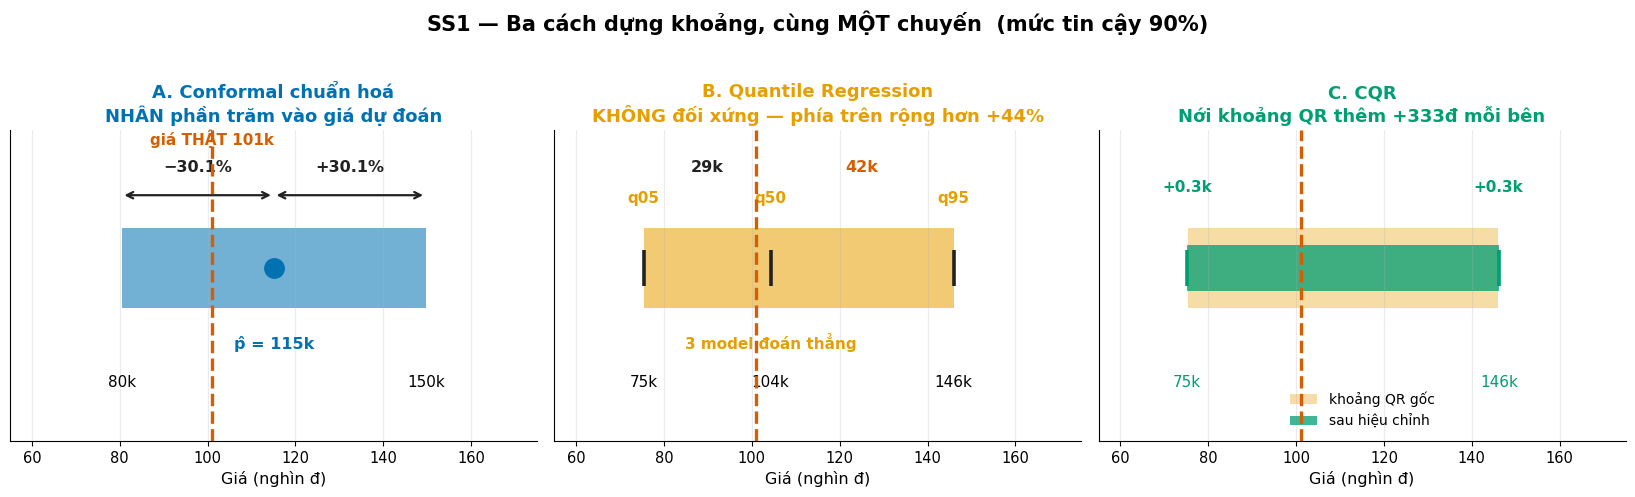

In [25]:
# ═════════ HINH SS1 — co che 3 phuong phap ═════════
i = i_ref                      # dung chung chuyen vi du voi cac hinh khac
p_hat, t_that = ut.hybrid_pred.values[i], that[i]

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))

# --- A ---
a = ax[0]
a.barh(0, (A_hi[i]-A_lo[i])/1000, left=A_lo[i]/1000, height=.42, color=BLUE, alpha=.55)
a.plot(p_hat/1000, 0, "o", color=BLUE, ms=14, zorder=5)
a.annotate("", xy=(A_lo[i]/1000, .38), xytext=(p_hat/1000, .38),
           arrowprops=dict(arrowstyle="<->", color=INK, lw=1.6))
a.annotate("", xy=(A_hi[i]/1000, .38), xytext=(p_hat/1000, .38),
           arrowprops=dict(arrowstyle="<->", color=INK, lw=1.6))
a.text((A_lo[i]+p_hat)/2000, .50, f"−{q_conf:.1%}", ha="center", fontsize=11.5,
       fontweight="bold", color=INK)
a.text((A_hi[i]+p_hat)/2000, .50, f"+{q_conf:.1%}", ha="center", fontsize=11.5,
       fontweight="bold", color=INK)
a.text(p_hat/1000, -.42, f"p̂ = {p_hat/1000:.0f}k", ha="center", fontsize=11.5,
       fontweight="bold", color=BLUE)
a.text(A_lo[i]/1000, -.62, f"{A_lo[i]/1000:.0f}k", ha="center", fontsize=11)
a.text(A_hi[i]/1000, -.62, f"{A_hi[i]/1000:.0f}k", ha="center", fontsize=11)
a.set_title("A. Conformal chuẩn hoá\nNHÂN phần trăm vào giá dự đoán",
            fontweight="bold", color=BLUE)

# --- B ---
b = ax[1]
b.barh(0, (B_hi[i]-B_lo[i])/1000, left=B_lo[i]/1000, height=.42, color=ORANGE, alpha=.55)
for v, ten, dy in [(qt.q05.values[i], "q05", 0), (qt.q50.values[i], "q50", 0),
                   (qt.q95.values[i], "q95", 0)]:
    b.plot(v/1000, 0, "|", color=INK, ms=26, mew=2.6, zorder=5)
    b.text(v/1000, .34, ten, ha="center", fontsize=11, fontweight="bold", color=ORANGE)
    b.text(v/1000, -.62, f"{v/1000:.0f}k", ha="center", fontsize=11)
d1 = (qt.q50.values[i]-B_lo[i])/1000
d2 = (B_hi[i]-qt.q50.values[i])/1000
b.text((B_lo[i]+qt.q50.values[i])/2000, .50, f"{d1:.0f}k", ha="center",
       fontsize=11.5, fontweight="bold", color=INK)
b.text((B_hi[i]+qt.q50.values[i])/2000, .50, f"{d2:.0f}k", ha="center",
       fontsize=11.5, fontweight="bold", color=RED)
b.text(qt.q50.values[i]/1000, -.42, "3 model đoán thẳng", ha="center",
       fontsize=11, fontweight="bold", color=ORANGE)
b.set_title(f"B. Quantile Regression\nKHÔNG đối xứng — phía trên rộng hơn {d2/d1-1:+.0%}",
            fontweight="bold", color=ORANGE)

# --- C ---
c = ax[2]
c.barh(0, (B_hi[i]-B_lo[i])/1000, left=B_lo[i]/1000, height=.42, color=ORANGE,
       alpha=.35, label="khoảng QR gốc")
c.barh(0, (C_hi[i]-C_lo[i])/1000, left=C_lo[i]/1000, height=.24, color=GREEN,
       alpha=.75, label="sau hiệu chỉnh")
for v in (C_lo[i], C_hi[i]):
    c.plot(v/1000, 0, "|", color=GREEN, ms=26, mew=2.6, zorder=5)
    c.text(v/1000, -.62, f"{v/1000:.0f}k", ha="center", fontsize=11, color=GREEN)
c.text((B_lo[i]+C_lo[i])/2000, .40, f"{q_cqr/1000:+.1f}k", ha="center",
       fontsize=11, fontweight="bold", color=GREEN)
c.text((B_hi[i]+C_hi[i])/2000, .40, f"{q_cqr/1000:+.1f}k", ha="center",
       fontsize=11, fontweight="bold", color=GREEN)
c.legend(frameon=False, loc="lower center", fontsize=10)
c.set_title(f"C. CQR\nNới khoảng QR thêm {q_cqr:+,.0f}đ mỗi bên",
            fontweight="bold", color=GREEN)

for a_ in ax:
    a_.axvline(t_that/1000, color=RED, lw=2.4, ls="--", zorder=6)
    a_.set_ylim(-.9, .72); a_.set_yticks([])
    a_.set_xlim(55, 175); a_.set_xlabel("Giá (nghìn đ)")
    a_.grid(axis="y", alpha=0)
ax[0].text(t_that/1000, .64, f"giá THẬT {t_that/1000:.0f}k", ha="center",
           fontsize=11, fontweight="bold", color=RED)

fig.suptitle(f"SS1 — Ba cách dựng khoảng, cùng MỘT chuyến  (mức tin cậy {MUC:.0%})",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "SS1_co_che_3_pp.png"); plt.show()

## 2. Kết quả — 3 phương pháp × 3 mức tin cậy

⚠️ **Độ rộng dưới đây là TRUNG BÌNH** trên 864.360 chuyến. Mỗi chuyến có khoảng riêng — chuyến rẻ
khoảng hẹp, chuyến đắt khoảng rộng.

In [26]:
MUCS = [0.70, 0.80, 0.90]
PV = {0.90: ("q05", "q95"), 0.80: ("q10", "q90"), 0.70: ("q15", "q85")}
TEN3 = ["Conformal chuẩn hoá", "QR thô", "CQR"]
MAU3 = [BLUE, ORANGE, GREEN]
O = {}      # (phuong phap, muc) -> dict

for m in MUCS:
    lo_c, hi_c = PV[m]

    # A. Conformal chuan hoa
    q = np.quantile(sai_cal, m)
    O[("Conformal chuẩn hoá", m)] = dict(
        lo=ut.hybrid_pred.values*(1-q), hi=ut.hybrid_pred.values*(1+q),
        tham_so=f"±{q:.2%}", q=q)

    # B. QR tho
    O[("QR thô", m)] = dict(lo=qt[lo_c].values, hi=qt[hi_c].values,
                            tham_so=f"{lo_c}–{hi_c}")

    # C. CQR
    E_ = np.maximum(qc[lo_c].values - qc.gia_that.values,
                    qc.gia_that.values - qc[hi_c].values)
    k_ = min(int(np.ceil((len(qc)+1)*m)), len(qc))
    qcq = np.sort(E_)[k_-1]
    O[("CQR", m)] = dict(lo=qt[lo_c].values - qcq, hi=qt[hi_c].values + qcq,
                         tham_so=f"{lo_c}–{hi_c} {qcq:+,.0f}đ", q_cqr=qcq)

for kk, v in O.items():
    trong = (that >= v["lo"]) & (that <= v["hi"])
    v["cov"] = trong.mean()
    v["rong"] = float(np.mean(v["hi"] - v["lo"]))
    v["trong"] = trong

# Cong bang giua nhom o muc 90% — dung cho Phan 4 va ket luan
_t = pd.DataFrame({"gio": qt.gio_vn.values, "km": qt.quang_duong.values})
_t["nhom_km"] = pd.qcut(_t.km, 8, labels=False, duplicates="drop")
_t["mua"] = qt.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values
for ten in PP:
    _t["tr"] = KQ[ten]["trong"]
    KQ[ten]["lech_dk"] = max(
        abs(_t.groupby("gio").tr.mean()*100 - MUC*100).max(),
        abs(_t.groupby("nhom_km").tr.mean()*100 - MUC*100).max(),
        abs(_t.groupby("mua").tr.mean()*100 - MUC*100).max())

# ═══ BANG A — do rong TRUNG BINH ═══
BA = pd.DataFrame(
    [[f"{O[(pp, m)]['rong']:,.0f}đ" for pp in TEN3] for m in MUCS],
    index=[f"{m:.0%}" for m in MUCS], columns=TEN3)
BA.index.name = "Độ tin cậy"
print("BANG A — KHOANG GIA TRUNG BINH (rong bao nhieu dong)")
display(BA)

# ═══ BANG B — coverage dat duoc ═══
BB = pd.DataFrame(
    [[f"{O[(pp, m)]['cov']:.2%}" for pp in TEN3] for m in MUCS],
    index=[f"{m:.0%}" for m in MUCS], columns=TEN3)
BB.index.name = "Độ tin cậy"
print("BANG B — COVERAGE DAT DUOC (so voi danh muc)")
display(BB)

BANG A — KHOANG GIA TRUNG BINH (rong bao nhieu dong)


,Conformal chuẩn hoá,QR thô,CQR
Độ tin cậy,,,
70%,"45,306đ","47,406đ","47,684đ"
80%,"56,134đ","58,772đ","59,284đ"
90%,"72,686đ","75,783đ","76,449đ"


BANG B — COVERAGE DAT DUOC (so voi danh muc)


,Conformal chuẩn hoá,QR thô,CQR
Độ tin cậy,,,
70%,69.68%,68.88%,69.26%
80%,79.62%,78.89%,79.44%
90%,89.58%,89.09%,89.54%


### Khoảng giá cụ thể — để nói cho dễ hình dung

Bảng trên là độ rộng trung bình. Bảng dưới là **khoảng thật của một chuyến cụ thể** — dạng này dễ
nói khi trình bày.

In [27]:
p_ref, t_ref = ut.hybrid_pred.values[i_ref], that[i_ref]

rows = []
for m in MUCS:
    for pp in TEN3:
        v = O[(pp, m)]
        rows.append({"Độ tin cậy": f"{m:.0%}", "Phương pháp": pp,
                     "Khoảng giá": f"{v['lo'][i_ref]:,.0f} – {v['hi'][i_ref]:,.0f}đ",
                     "Rộng": f"{v['hi'][i_ref]-v['lo'][i_ref]:,.0f}đ",
                     "Trúng?": "trúng" if v["lo"][i_ref] <= t_ref <= v["hi"][i_ref]
                               else "TRƯỢT"})
BC = pd.DataFrame(rows)
print(f"BANG C — CHUYEN VI DU: gia du doan {p_ref:,.0f}d  |  gia THAT {t_ref:,.0f}d")
display(BC.pivot(index="Độ tin cậy", columns="Phương pháp",
                 values="Khoảng giá").reindex([f"{m:.0%}" for m in MUCS])[TEN3])
display(BC)

BANG C — CHUYEN VI DU: gia du doan 115,044d  |  gia THAT 101,000d


Phương pháp,Conformal chuẩn hoá,QR thô,CQR
Độ tin cậy,,,
70%,"93,453 – 136,634đ","86,604 – 124,170đ","86,465 – 124,309đ"
80%,"88,293 – 141,794đ","82,876 – 131,428đ","82,620 – 131,684đ"
90%,"80,405 – 149,682đ","75,379 – 145,960đ","75,046 – 146,293đ"


,Độ tin cậy,Phương pháp,Khoảng giá,Rộng,Trúng?
0,70%,Conformal chuẩn hoá,"93,453 – 136,634đ","43,181đ",trúng
1,70%,QR thô,"86,604 – 124,170đ","37,566đ",trúng
2,70%,CQR,"86,465 – 124,309đ","37,844đ",trúng
3,80%,Conformal chuẩn hoá,"88,293 – 141,794đ","53,502đ",trúng
4,80%,QR thô,"82,876 – 131,428đ","48,552đ",trúng
5,80%,CQR,"82,620 – 131,684đ","49,064đ",trúng
6,90%,Conformal chuẩn hoá,"80,405 – 149,682đ","69,277đ",trúng
7,90%,QR thô,"75,379 – 145,960đ","70,580đ",trúng
8,90%,CQR,"75,046 – 146,293đ","71,246đ",trúng


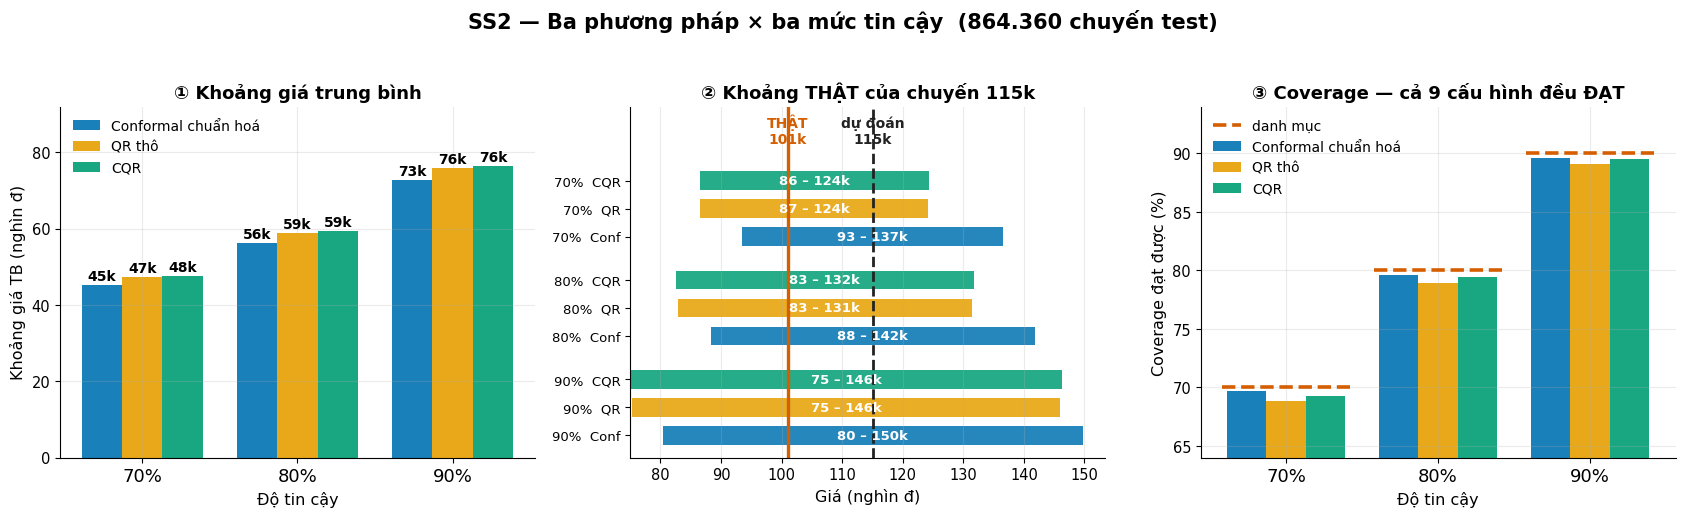

NHAN XET:
  Doi MUC 90%->70% : khoang hep 38%
  Doi PHUONG PHAP  : chenh chi 5.2%
  => Chon MUC anh huong lon hon nhieu so voi chon PHUONG PHAP.


In [28]:
# ═════════ HINH SS2 — 3 phuong phap x 3 muc ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5.0))
x = np.arange(3); w = .26

# ① Do rong TB
for j, pp in enumerate(TEN3):
    v = [O[(pp, m)]["rong"]/1000 for m in MUCS]
    b = ax[0].bar(x + (j-1)*w, v, w, color=MAU3[j], alpha=.9, label=pp)
    for bb, val in zip(b, v):
        ax[0].text(bb.get_x()+bb.get_width()/2, val+1.3, f"{val:.0f}k",
                   ha="center", fontsize=10, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=13)
ax[0].set_xlabel("Độ tin cậy"); ax[0].set_ylabel("Khoảng giá TB (nghìn đ)")
ax[0].set_ylim(0, 92); ax[0].legend(frameon=False, fontsize=10)
ax[0].set_title("① Khoảng giá trung bình", fontweight="bold")

# ② Khoang that cua chuyen vi du
y = 0
nhan_y, nhan_t = [], []
for m in sorted(MUCS, reverse=True):
    for j, pp in enumerate(TEN3):
        v = O[(pp, m)]
        lo_, hi_ = v["lo"][i_ref]/1000, v["hi"][i_ref]/1000
        ax[1].barh(y, hi_-lo_, left=lo_, height=.66, color=MAU3[j], alpha=.85)
        ax[1].text((lo_+hi_)/2, y, f"{lo_:.0f} – {hi_:.0f}k", ha="center",
                   va="center", fontsize=9.5, fontweight="bold", color="white")
        nhan_y.append(y); nhan_t.append(f"{m:.0%}  {['Conf','QR','CQR'][j]}")
        y += 1
    y += .55
ax[1].axvline(p_ref/1000, color=INK, lw=2, ls="--")
ax[1].axvline(t_ref/1000, color=RED, lw=2.4)
ax[1].text(p_ref/1000, y-.2, f"dự đoán\n{p_ref/1000:.0f}k", ha="center",
           fontsize=10, fontweight="bold", color=INK)
ax[1].text(t_ref/1000, y-.2, f"THẬT\n{t_ref/1000:.0f}k", ha="center",
           fontsize=10, fontweight="bold", color=RED)
ax[1].set_yticks(nhan_y); ax[1].set_yticklabels(nhan_t, fontsize=9.5)
ax[1].set_xlabel("Giá (nghìn đ)"); ax[1].set_ylim(-.8, y+1.1)
ax[1].grid(axis="y", alpha=0)
ax[1].set_title(f"② Khoảng THẬT của chuyến {p_ref/1000:.0f}k", fontweight="bold")

# ③ Coverage
for j, pp in enumerate(TEN3):
    v = [O[(pp, m)]["cov"]*100 for m in MUCS]
    ax[2].bar(x + (j-1)*w, v, w, color=MAU3[j], alpha=.9, label=pp)
for j_, m in enumerate(MUCS):
    ax[2].plot([j_-.42, j_+.42], [m*100, m*100], color=RED, lw=2.6, ls="--", zorder=5)
ax[2].plot([], [], color=RED, lw=2.6, ls="--", label="danh mục")
ax[2].set_xticks(x); ax[2].set_xticklabels([f"{m:.0%}" for m in MUCS], fontsize=13)
ax[2].set_xlabel("Độ tin cậy"); ax[2].set_ylabel("Coverage đạt được (%)")
ax[2].set_ylim(64, 94); ax[2].legend(frameon=False, fontsize=10)
ax[2].set_title("③ Coverage — cả 9 cấu hình đều ĐẠT", fontweight="bold")

fig.suptitle("SS2 — Ba phương pháp × ba mức tin cậy  (864.360 chuyến test)",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "SS2_ket_qua.png"); plt.show()

print("NHAN XET:")
r90 = [O[(pp, 0.90)]["rong"] for pp in TEN3]
r70 = [O[(pp, 0.70)]["rong"] for pp in TEN3]
print(f"  Doi MUC 90%->70% : khoang hep {(1-np.mean(r70)/np.mean(r90))*100:.0f}%")
print(f"  Doi PHUONG PHAP  : chenh chi {(max(r90)/min(r90)-1)*100:.1f}%")
print("  => Chon MUC anh huong lon hon nhieu so voi chon PHUONG PHAP.")

### Đọc bảng

| Độ tin cậy | Khoảng giá trung bình |
|---|---|
| **90%** | ~72.700 – 76.400đ tuỳ phương pháp |
| **80%** | ~56.100 – 59.300đ |
| **70%** | ~45.300 – 47.700đ |

**Hai điều rút ra:**

1. **Chọn mức tin cậy quan trọng hơn chọn phương pháp.** Hạ từ 90% xuống 70% làm khoảng hẹp
   **~38%**. Còn đổi phương pháp trong cùng một mức chỉ chênh **~5%**.
2. **Cả 9 cấu hình đều đạt coverage danh mục** — nên tiêu chí này không phân biệt được. Thứ phân
   biệt nằm ở Phần 4.

## 3. Trên chuyến thật thì khác nhau thế nào

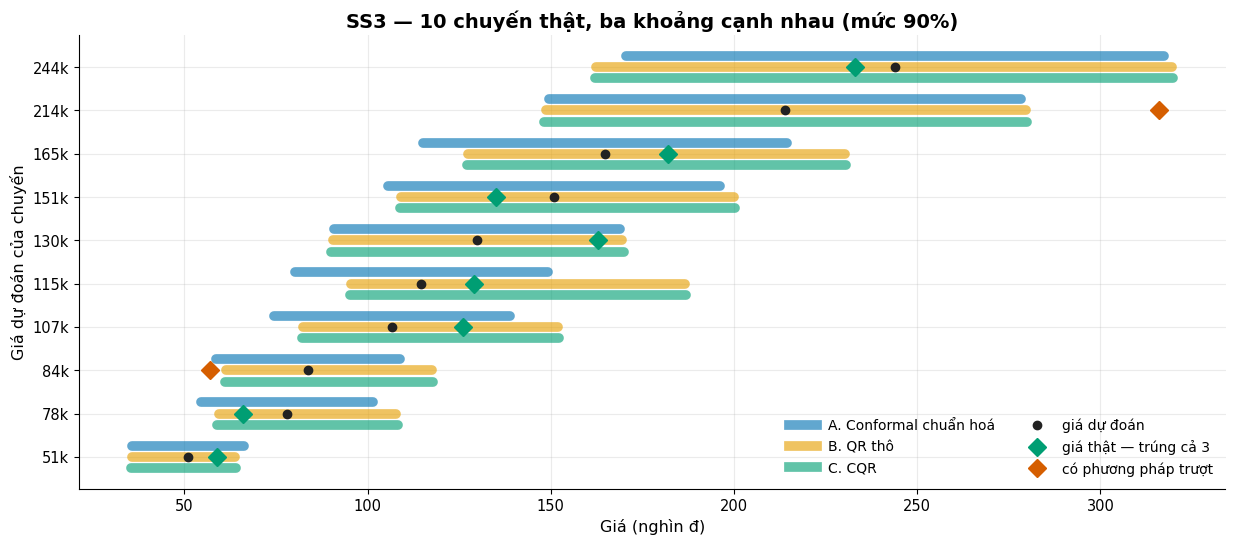

Chu y: chuyen cang dat, khoang cang rong — vi khoang nhan theo gia du doan.
Do rong khong co dinh: p10 ~45k, p90 ~104k (conformal).


In [29]:
# ═════════ HINH SS3 — 10 chuyen that ═════════
rng = np.random.default_rng(3)
n = 10
idx = rng.choice(len(qt), n, replace=False)
idx = idx[np.argsort(ut.hybrid_pred.values[idx])]

fig, ax = plt.subplots(figsize=(12.5, 5.6))
off = {0: .26, 1: 0.0, 2: -.26}
for j, ten in enumerate(PP):
    lo, hi, col = PP[ten]
    for r, i_ in enumerate(idx):
        ax.plot([lo[i_]/1000, hi[i_]/1000], [r+off[j]]*2, lw=7, color=col,
                alpha=.62, solid_capstyle="round")
for r, i_ in enumerate(idx):
    ax.plot(ut.hybrid_pred.values[i_]/1000, r, "o", color=INK, ms=6, zorder=5)
    trung = all(PP[k][0][i_] <= that[i_] <= PP[k][1][i_] for k in PP)
    ax.plot(that[i_]/1000, r, "D", ms=9, zorder=6,
            color=GREEN if trung else RED)
for j, ten in enumerate(PP):
    ax.plot([], [], lw=7, color=PP[ten][2], alpha=.62, label=ten)
ax.plot([], [], "o", color=INK, ms=6, label="giá dự đoán")
ax.plot([], [], "D", color=GREEN, ms=9, label="giá thật — trúng cả 3")
ax.plot([], [], "D", color=RED, ms=9, label="có phương pháp trượt")
ax.set_yticks(range(n))
ax.set_yticklabels([f"{ut.hybrid_pred.values[i]/1000:.0f}k" for i in idx])
ax.set_ylabel("Giá dự đoán của chuyến"); ax.set_xlabel("Giá (nghìn đ)")
ax.legend(frameon=False, ncol=2, loc="lower right", fontsize=10)
ax.set_title(f"SS3 — 10 chuyến thật, ba khoảng cạnh nhau (mức {MUC:.0%})",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.savefig(HINH / "SS3_chuyen_that.png"); plt.show()

print("Chu y: chuyen cang dat, khoang cang rong — vi khoang nhan theo gia du doan.")
print("Do rong khong co dinh: p10 ~45k, p90 ~104k (conformal).")

## 4. ⭐ Trục đánh giá thứ hai — **khả năng tích hợp**

Mentor hỏi: *"uncertainty model nào **dùng được và hợp lý để integrate** vào model ở mục (ii)"*.

Xét thuần thống kê thì 3 phương pháp tương đương (Phần 2). Thứ **thật sự phân biệt** là chỗ này.

Model của mục (ii) **không phải một model** — nó là tích của hai:

```
giá = Model_A(giá cơ bản) × Model_B(hệ số nhân)
```

Và bất định **không chia đều**: hệ số nhân R² **0,9609** (rất chắc), giá cơ bản R² **0,6564**
(nút thắt). Gần như toàn bộ bất định đến từ **giá cơ bản**.

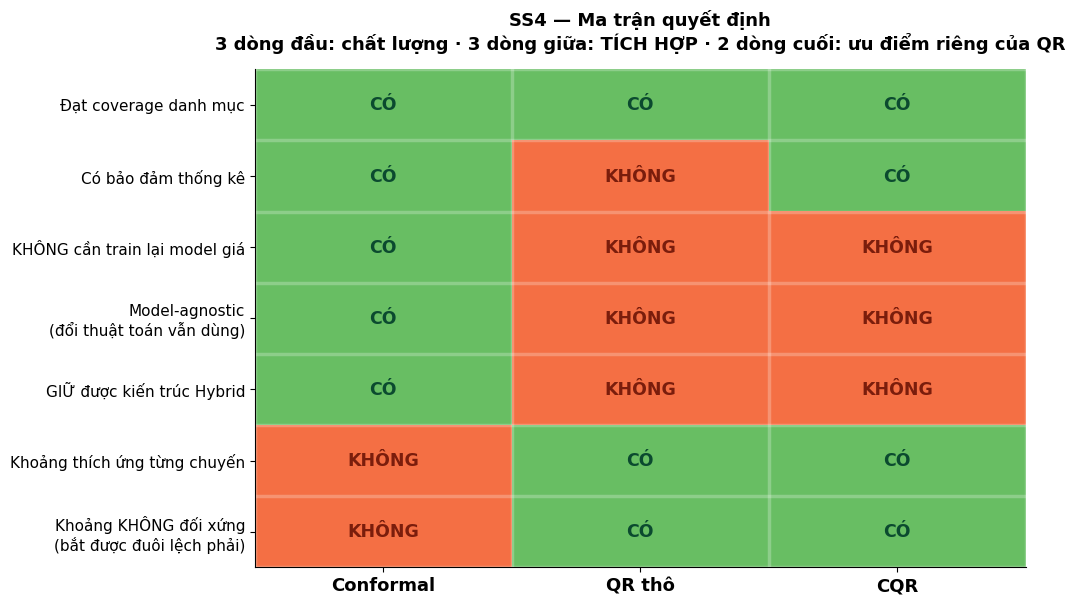

Tong so tieu chi dat duoc:
  Conformal    5/7
  QR thô       3/7
  CQR          4/7


In [30]:
# ═════════ HINH SS4 — ma tran quyet dinh ═════════
TIEU_CHI = ["Đạt coverage danh mục", "Có bảo đảm thống kê",
            "KHÔNG cần train lại model giá", "Model-agnostic\n(đổi thuật toán vẫn dùng)",
            "GIỮ được kiến trúc Hybrid", "Khoảng thích ứng từng chuyến",
            "Khoảng KHÔNG đối xứng\n(bắt được đuôi lệch phải)"]
DIEM = np.array([
    [1, 1, 1],      # dat coverage
    [1, 0, 1],      # bao dam
    [1, 0, 0],      # khong can train lai
    [1, 0, 0],      # model-agnostic
    [1, 0, 0],      # giu Hybrid
    [0, 1, 1],      # thich ung
    [0, 1, 1],      # khong doi xung
])

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.imshow(DIEM, cmap="RdYlGn", vmin=-.35, vmax=1.35, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(ngan, fontsize=13, fontweight="bold")
ax.set_yticks(range(len(TIEU_CHI))); ax.set_yticklabels(TIEU_CHI, fontsize=11)
for r in range(DIEM.shape[0]):
    for cc in range(DIEM.shape[1]):
        ax.text(cc, r, "CÓ" if DIEM[r, cc] else "KHÔNG", ha="center", va="center",
                fontsize=12.5, fontweight="bold",
                color="#0B4A2F" if DIEM[r, cc] else "#7A1D0C")
ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(TIEU_CHI), 1), minor=True)
ax.grid(which="minor", color="white", lw=2.5); ax.tick_params(which="minor", length=0)
ax.grid(which="major", alpha=0)
ax.set_title("SS4 — Ma trận quyết định\n3 dòng đầu: chất lượng · 3 dòng giữa: TÍCH HỢP · "
             "2 dòng cuối: ưu điểm riêng của QR",
             fontweight="bold", fontsize=13, pad=14)
plt.tight_layout(); plt.savefig(HINH / "SS4_ma_tran_quyet_dinh.png"); plt.show()

tong = DIEM.sum(axis=0)
print("Tong so tieu chi dat duoc:")
for ten, s in zip(ngan, tong):
    print(f"  {ten:12s} {s}/{len(TIEU_CHI)}")

## 5. Kết luận

In [31]:
# Tinh lai tai cho de khong phu thuoc bien o cell truoc
cov_ds = [KQ[k]["cov"] for k in PP]
rong_ds = [KQ[k]["rong"] for k in PP]

print("╔" + "═"*72 + "╗")
print("║" + " CAU PHAN (iii) — KET LUAN ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print(f"  {'':26s} {'Coverage':>10s} {'Do rong TB':>13s} {'Cong bang':>11s}")
print("  " + "-"*64)
for ten in PP:
    r = KQ[ten]
    print(f"  {ten:26s} {r['cov']:>9.2%} {r['rong']:>12,.0f}d {r['lech_dk']:>10.2f}")
print()
print("  XET THUAN THONG KE:  ca 3 tuong duong")
print(f"     coverage chenh {(max(cov_ds)-min(cov_ds))*100:.2f} diem  |  "
      f"do rong chenh {(max(rong_ds)/min(rong_ds)-1)*100:.1f}%")
print()
print("  XET KHA NANG TICH HOP:  Conformal thang ro")
print("     · KHONG can train lai model gia — boc quanh model co san")
print("     · Model-agnostic — doi thuat toan van dung duoc")
print("     · GIU nguyen kien truc Hybrid cua muc (ii)")
print()
print("─"*74)
print("  => CHON: Conformal chuan hoa lam MAC DINH")
print("     CQR lam phuong an du phong khi can khoang thich ung / khong doi xung")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                       CAU PHAN (iii) — KET LUAN                        ║
╚════════════════════════════════════════════════════════════════════════╝

                               Coverage    Do rong TB   Cong bang
  ----------------------------------------------------------------
  A. Conformal chuẩn hoá        89.58%       72,686d       2.04
  B. QR thô                     89.09%       75,783d       2.36
  C. CQR                        89.54%       76,449d       1.91

  XET THUAN THONG KE:  ca 3 tuong duong
     coverage chenh 0.49 diem  |  do rong chenh 5.2%

  XET KHA NANG TICH HOP:  Conformal thang ro
     · KHONG can train lai model gia — boc quanh model co san
     · Model-agnostic — doi thuat toan van dung duoc
     · GIU nguyen kien truc Hybrid cua muc (ii)

──────────────────────────────────────────────────────────────────────────
  => CHON: Conformal chuan hoa lam MAC DINH
     CQR lam phuong an du 

### Câu trả lời cho câu hỏi của mentor

> *"Uncertainty model nào sẽ dùng được và hợp lý để **integrate** vào model ở mục (ii)?"*

**Chọn Conformal chuẩn hoá**, ba lý do:

**1. Không cần train lại gì cả.** Chỉ cần model giá đã có + một tập calibration. Model của mục (ii)
giữ nguyên 100%.

**2. Model-agnostic.** Sau này đổi thuật toán, đổi feature, đổi kiến trúc — phần UQ vẫn dùng được,
chỉ hiệu chỉnh lại **một con số**.

**3. Giữ được kiến trúc Hybrid.** Đây là lý do quyết định. Conformal bọc quanh **kết quả cuối** nên
không quan tâm bên trong là một hay hai model. QR/CQR buộc phải train **thẳng trên giá cuối**, tức
là **bỏ mất cấu trúc Hybrid** — mà chính cấu trúc đó cho model tốt hơn 4% và thắng **24/24 giờ**.

### CQR vẫn có chỗ dùng

| Ưu điểm riêng | Ý nghĩa |
|---|---|
| Khoảng **thích ứng từng chuyến** | Không tỷ lệ cứng với giá — bám độ khó thật của chuyến |
| Khoảng **không đối xứng** | Phía trên rộng hơn ~36%, đúng với việc surge chỉ nhân lên chứ không nhân xuống |

Để làm **phương án dự phòng**, không làm mặc định.

### ⚠️ Ba điều phải nói rõ khi trình bày

| Điểm | Phát biểu đúng |
|---|---|
| Số tổng hợp vs số một chuyến | *"Khoảng **trung bình** rộng 72.686đ"* — không phải khoảng của chuyến nào cụ thể |
| Thứ tự nhân quả | Ta **chọn** mức tin cậy trước, khoảng là kết quả — không phải ngược lại |
| Không bảo đảm tuyệt đối | *"Với độ tin cậy 90%"* — bỏ cụm này đi là thành lời hứa chắc chắn |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `SS1_co_che_3_pp` | Ba cách dựng khoảng, cùng một chuyến |
| `SS2_ket_qua` | Coverage · độ rộng · công bằng trên 864.360 chuyến |
| `SS3_chuyen_that` | 10 chuyến thật, ba khoảng cạnh nhau |
| ⭐ `SS4_ma_tran_quyet_dinh` | Ma trận 7 tiêu chí — trả lời câu hỏi *integrate* |

## Chi tiết kỹ thuật

| Notebook | Nội dung |
|---|---|
| `01_conformal_prediction` · `02_quantile_va_CQR` | Cài đặt gốc |
| `03_truc_quan_UQ` | Cơ chế conformal, vì sao phải chuẩn hoá |
| `04_UQ_theo_quang_duong` | Mondrian — chia nhóm có hiệu quả không |
| `05_chon_muc_tin_cay` | Chọn 70 / 80 / 90% |
| `06_ba_pp_ba_muc` | Lưới đầy đủ 3 phương pháp × 3 mức |